#Task 4: Predictive Modeling for Risk-Based Pricing System

In [57]:
!pip install scikit-learn

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv('../MachineLearningRating_v3.txt', delimiter='|', encoding='utf-8', low_memory=False)
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

In [60]:
print(df.columns)

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')


In [61]:
# Filter for regression task
df_claims = df[df['TotalClaims'] >= 0].copy()
df['HasClaim'] = df['TotalClaims'] > 0

In [62]:
# Create derived columns
df['HasClaim'] = df['TotalClaims'] > 0
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

In [63]:
# Drop columns with too many missing or high cardinality IDs
df.columns = df.columns.str.strip()
drop_cols = ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth']
#df = df.drop(["UnderwrittenCoverID", "PolicyID", 'TransactionMonth'], axis=1)

#df.drop(columns=drop_cols, inplace=True)
df_claims.drop(columns=drop_cols)

,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000094,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000095,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000096,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,...,No excess,Passenger Liability,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0


In [64]:
# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [65]:
nan_columns = df.columns[df.isnull().all()]
print("Columns with only NaN values:", nan_columns.tolist())

Columns with only NaN values: ['NumberOfVehiclesInFleet']


In [66]:
df = df.dropna(axis=1, how='all')  # Removes columns that are entirely NaN

In [67]:
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = imputer.fit_transform(df)
df = pd.DataFrame(df_imputed, columns=df.columns)  # Ensure column names match

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

imputer = SimpleImputer(strategy="most_frequent") 
print(df.shape)  # Before imputation
df_imputed = imputer.fit_transform(df)
print(df_imputed.shape)  # After imputation

(1000098, 53)
(1000098, 53)


In [69]:
!pip install xgboost

In [70]:
 #Claim Severity Modeling (Regression)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [71]:
# Subset to only policies with claims
from sklearn.model_selection import train_test_split
claim_df = df[df['HasClaim'] == 1]
X = claim_df.drop(columns=['TotalClaims', 'HasClaim'])
y = claim_df['TotalClaims']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#check X_train in not 0 while a minimum of 1 is required by LinearRegression.
print(X_train.shape) 
print(X_train.head())

(2230, 51)
        UnderwrittenCoverID  PolicyID  TransactionMonth  IsVATRegistered  \
191385              32486.0    2419.0              20.0              0.0   
487085             113296.0    7685.0              14.0              0.0   
714126             139463.0   11507.0              17.0              0.0   
38476              126032.0    6641.0              16.0              0.0   
95322              123395.0   10423.0              17.0              0.0   

        Citizenship  LegalType  Title  Language  Bank  AccountType  ...  \
191385          0.0        1.0    2.0       0.0   0.0          1.0  ...   
487085          0.0        1.0    2.0       0.0   7.0          1.0  ...   
714126          0.0        1.0    2.0       0.0  10.0          1.0  ...   
38476           0.0        1.0    2.0       0.0   0.0          0.0  ...   
95322           0.0        1.0    2.0       0.0   0.0          0.0  ...   

        ExcessSelected  CoverCategory  CoverType  CoverGroup  Section  \
191385  

In [72]:
print(X_train.dtypes, y_train.dtypes)

UnderwrittenCoverID         float64
PolicyID                    float64
TransactionMonth            float64
IsVATRegistered             float64
Citizenship                 float64
LegalType                   float64
Title                       float64
Language                    float64
Bank                        float64
AccountType                 float64
MaritalStatus               float64
Gender                      float64
Country                     float64
Province                    float64
PostalCode                  float64
MainCrestaZone              float64
SubCrestaZone               float64
ItemType                    float64
mmcode                      float64
VehicleType                 float64
RegistrationYear            float64
make                        float64
Model                       float64
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                    float64
NumberOfDoors               

In [73]:
X_train.fillna(0)  # Replace NaNs with 0

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,Margin
191385,32486.0,2419.0,20.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,...,10.0,26.0,21.0,5.0,1.0,1.0,0.0,0.0,21.929825,-1339.473684
487085,113296.0,7685.0,14.0,0.0,0.0,1.0,2.0,0.0,7.0,1.0,...,12.0,11.0,11.0,9.0,2.0,1.0,0.0,0.0,74.561404,-6065.789474
714126,139463.0,11507.0,17.0,0.0,0.0,1.0,2.0,0.0,10.0,1.0,...,10.0,26.0,21.0,5.0,1.0,1.0,0.0,0.0,21.929825,-1381.578947
38476,126032.0,6641.0,16.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,...,4.0,15.0,13.0,5.0,1.0,1.0,0.0,0.0,420.249737,-15700.995877
95322,123395.0,10423.0,17.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,...,10.0,26.0,21.0,5.0,1.0,1.0,0.0,0.0,21.929825,-728.719298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541079,89820.0,7811.0,14.0,0.0,0.0,1.0,2.0,0.0,11.0,0.0,...,12.0,21.0,18.0,5.0,1.0,1.0,0.0,0.0,216.317368,-9216.094912
348365,68402.0,5247.0,18.0,0.0,0.0,1.0,2.0,0.0,2.0,0.0,...,12.0,11.0,11.0,9.0,2.0,2.0,0.0,0.0,74.561404,-3872.807018
356353,195396.0,17356.0,17.0,0.0,0.0,1.0,2.0,0.0,2.0,1.0,...,6.0,14.0,13.0,5.0,1.0,1.0,0.0,0.0,278.378325,-7003.244482
412979,81665.0,6462.0,13.0,0.0,0.0,1.0,2.0,0.0,2.0,1.0,...,10.0,26.0,21.0,5.0,1.0,1.0,0.0,0.0,21.929825,-460.526316


In [74]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [75]:
# Model 2: Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [76]:
# Model 3: XGBoost
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [77]:
# Evaluation
for name, y_pred in zip(['Linear Regression', 'Random Forest', 'XGBoost'],
                        [y_pred_lr, y_pred_rf, y_pred_xgb]):
    print(f"\n{name}:")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R^2:", r2_score(y_test, y_pred))


Linear Regression:
RMSE: 2.091801990332506e-10
R^2: 1.0

Random Forest:
RMSE: 3372.7731080236226
R^2: 0.9929267137191755

XGBoost:
RMSE: 4088.9824615039925
R^2: 0.9896037317113312


In [78]:
#Claim Probability Modeling (Classification)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBRegressor

X_class = df.drop(columns=['TotalClaims', 'HasClaim'])
y_class = df['HasClaim']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)


In [79]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error

# Splitting data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Initialize and train the model
model = HistGradientBoostingRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.4f}')

Mean Squared Error: 15522079.7478


In [80]:
print("✅ Training shape:", X_train_c.shape)
print("✅ Test shape:", X_test_c.shape)
print("✅ Unique targets:", np.unique(y_train_c))


✅ Training shape: (800078, 51)
✅ Test shape: (200020, 51)
✅ Unique targets: [0. 1.]


In [ ]:
# Classification Model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)
models_cls = {
    'RandomForest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier()
}
print(classification_report(y_test_c, y_pred_c))
print("ROC-AUC:", roc_auc_score(y_test_c, clf.predict_proba(X_test_c)[:, 1]))


In [82]:
#Premium Estimation Framework

# Estimate Risk-Based Premium
predicted_probability = clf.predict_proba(X_class)[:, 1]
predicted_severity = xgb.predict(X_class)

In [83]:
# Risk-based premium = probability * severity + fixed loading + margin
expense_loading = 300  
profit_margin = 0.10

risk_based_premium = predicted_probability * predicted_severity + expense_loading + profit_margin * predicted_severity
df['PredictedPremium'] = risk_based_premium 

In [84]:
!pip install shap


 98%|===================| 2185/2230 [00:15<00:00]        

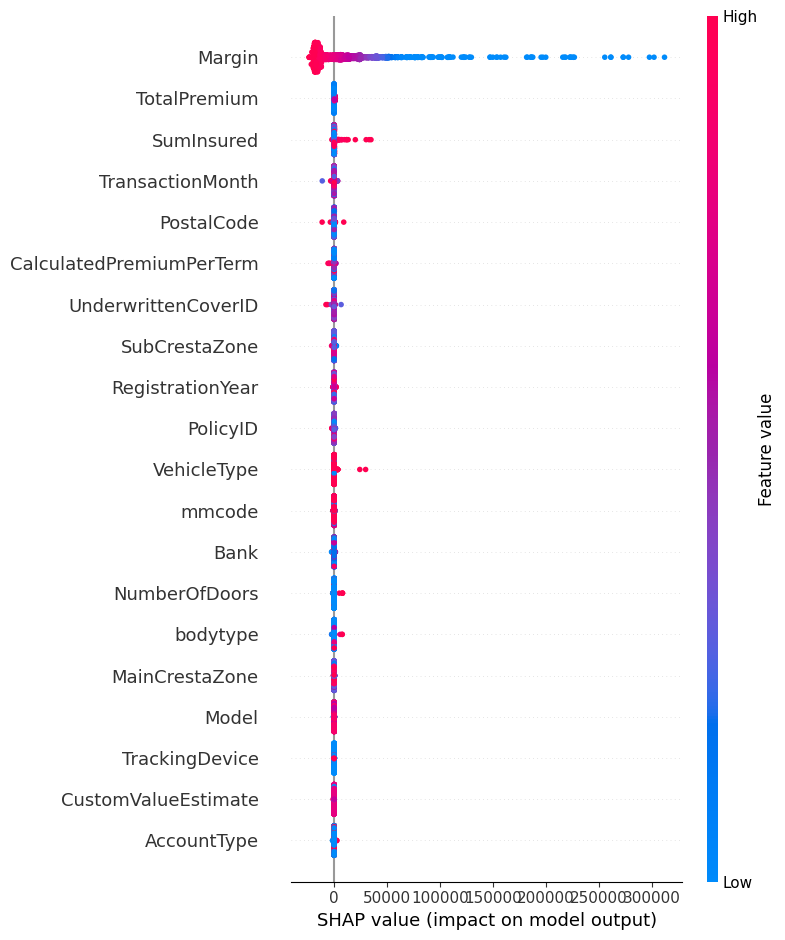

In [85]:
import shap

# Fit model
xgb = XGBRegressor(objective='reg:squarederror')
xgb.fit(X_train, y_train)

# Use original (raw) data for SHAP, NOT preprocessed arrays
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_train)

# Show summary plot
shap.summary_plot(shap_values, X_train)
